(60, 369, 144) (60, 369, 144)
(42, 382, 165) (42, 382, 165)
(23, 314, 251) (23, 314, 251)
(25, 158, 404) (25, 158, 404)


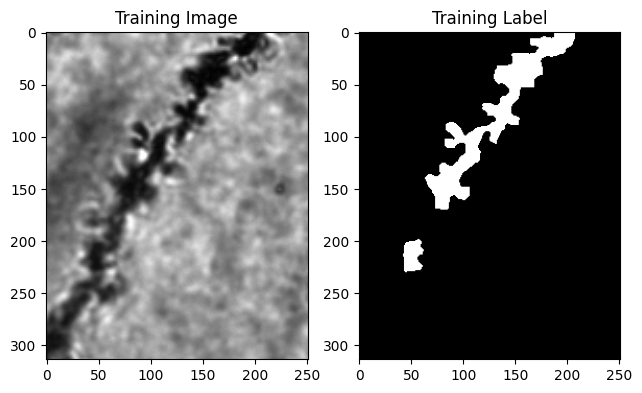

In [32]:
import matplotlib.pyplot as plt
import imageio
import cv2
import numpy as np
import random
from PIL import Image, ImageOps
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from collections import Counter
from torchsummary import summary
from sklearn.metrics import f1_score, accuracy_score

p1 = '2_image.tiff'
p2 = '3_image.tiff'
p3 = '6_image.tiff'
p4 = '7_image.tiff'
l1 = '2_mask.tiff'
l2 = '3_mask.tiff'
l3 = '6_mask.tiff'
l4 = '7_mask.tiff'

def resize_images(image_array, target_size=(400, 400)):
    resized_images = []
    for img_data in image_array:
        img = Image.fromarray(img_data)
        img_resized = cv2.resize(img_data, target_size, interpolation=cv2.INTER_NEAREST)
        resized_images.append(np.array(img_resized))
    return np.array(resized_images)

def data_augmentation(data):
    flipped_horizontal = [cv2.flip(img, 1) for img in data]
    rotated_C = [cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE) for img in data]
    rotated_C_flipped = [cv2.flip(img, 0) for img in rotated_C]
    rotated_CW = [cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE) for img in data]
    rotated_CW_flipped = [cv2.flip(img, 0) for img in rotated_CW]
    flipped_both = [cv2.flip(img, -1) for img in data]
    rotated_180 = [cv2.rotate(img, cv2.ROTATE_180) for img in data]
    return np.concatenate([data, flipped_horizontal, rotated_C, rotated_C_flipped,rotated_CW,rotated_CW_flipped,flipped_both,rotated_180], axis=0)

# Load the TIF stack
x1 = imageio.volread(p1)
x2 = imageio.volread(p2)
x3 = imageio.volread(p3)
x4 = imageio.volread(p4)
y1 = imageio.volread(l1)
y2 = imageio.volread(l2)
y3 = imageio.volread(l3)
y4 = imageio.volread(l4)
print(x1.shape,y1.shape)
print(x2.shape,y2.shape)
print(x3.shape,y3.shape)
print(x4.shape,y4.shape)
X = x3
Y = y3
#X = resize_images(X)
#Y = resize_images(Y)

# Choose a random index to display images
random_index = 15
# Plot the training image
plt.subplot(1, 2, 1)
plt.imshow(X[random_index], cmap='gray')
plt.title('Training Image')

# Plot the corresponding label
plt.subplot(1, 2, 2)
plt.imshow(Y[random_index], cmap='gray')
plt.title('Training Label')

plt.tight_layout()
plt.show()




314 251


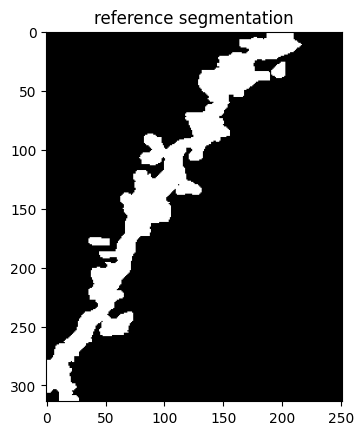

In [65]:
# create the reference mask

first_masked_image = Y[0]
height, width = first_masked_image.shape
print(height,width)
# Initialize a blank mask image
final_mask = np.zeros((height, width), dtype=np.uint8)

# Iterate over each pixel location
for i in range(height):
    for j in range(width):
        # Check if any pixel at the same location from the list is white
        for masked_image in Y:
            if masked_image[i, j] == 255:  # Assuming white is represented by 255
                # Set the pixel in the final mask to white
                final_mask[i, j] = 255
                break  # Break out of the loop once a white pixel is found

final_image_mask = np.stack((final_mask,) * 3, axis=-1)
plt.title("reference segmentation")
plt.imshow(final_image_mask,cmap="gray")
plt.show()

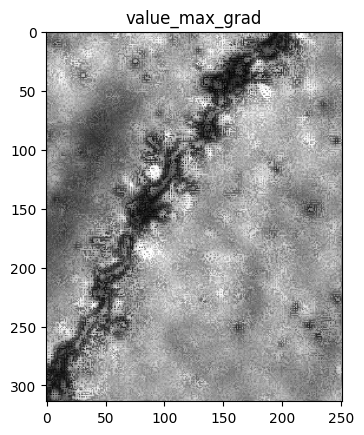

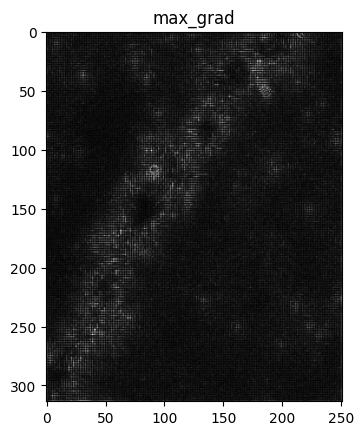

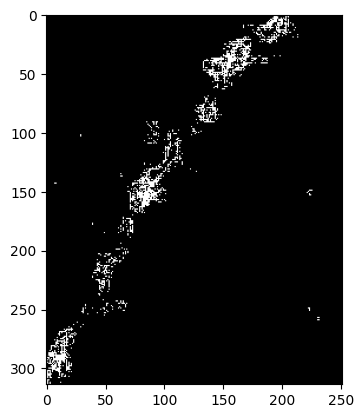

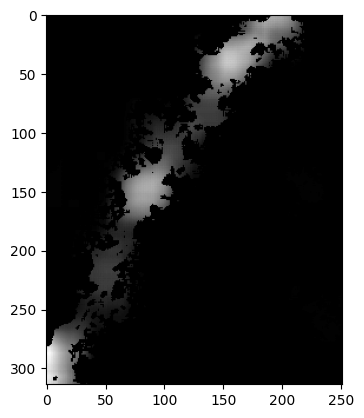

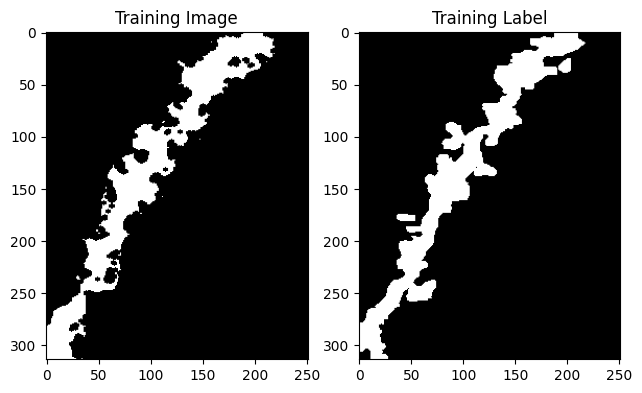

In [135]:
def lapla_blur(img):
    kernel_size = 1    
    blur_size = 1          
    img = cv2.GaussianBlur(img, (blur_size,blur_size), 0)
    img = cv2.Laplacian(img, cv2.CV_64F, ksize=kernel_size)
    img = np.absolute(img)
    return img

x_grad = np.array([lapla_blur(x) for x in X])

height, width = X[0].shape

max_indices = np.zeros((height, width), dtype=np.uint8)
max_grad = np.zeros((height, width), dtype=np.uint8)

value_max_grad = np.zeros((height, width), dtype=np.uint8)

# Iterate over each pixel location
for y in range(height):
    for x in range(width):
        # Extract pixel values for the current location from all images
        pixel_values = [image[y, x] for image in x_grad]
        # Find the index of the maximum value among all images
        max_index = np.argmax(pixel_values)
        max_grad[y,x] = np.max(pixel_values)
        max_indices[y, x] = max_index
        value_max_grad[y,x] = X[max_index][y][x]
plt.title("value_max_grad")
plt.imshow(value_max_grad,cmap="gray")
plt.show()
plt.title("max_grad")
plt.imshow(max_grad,cmap="gray")
plt.show()

#blur_max_grad = cv2.GaussianBlur(value_max_grad,(19,19),1)
blur_value_max_grad = cv2.medianBlur(value_max_grad,3)
blur_max_grad = cv2.medianBlur(max_grad ,3)
'''
plt.imshow(blur_value_max_grad,cmap="gray")
plt.show()
plt.imshow(blur_max_grad,cmap="gray")
plt.show()
''' 
_, otsu_thresh_value = cv2.threshold(blur_value_max_grad, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, otsu_thresh_value_inv = cv2.threshold(blur_value_max_grad, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
_, otsu_thresh_grad= cv2.threshold(blur_max_grad, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
'''
plt.title("otsu_thresh_value")
plt.imshow(otsu_thresh_value,cmap="gray")
plt.show()
plt.title("otsu_thresh_value_inv")
plt.imshow(otsu_thresh_value_inv,cmap="gray")
plt.show()
'''
# Apply masking
masked_image = cv2.bitwise_and(value_max_grad, otsu_thresh_value_inv)
#plt.imshow(masked_image,cmap="gray")
#plt.show()
_, masked_image_threshold = cv2.threshold(masked_image, 40, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#plt.imshow(masked_image_threshold,cmap="gray")
#plt.show()


highlighted_image = np.zeros_like(masked_image_threshold)
for y in range(masked_image_threshold.shape[0]):
    for x in range(masked_image_threshold.shape[1]):
        # Compare pixel values from the two images
        if masked_image_threshold[y, x] != otsu_thresh_value_inv[y, x]:
            # Highlight the pixel in the output image
            highlighted_image[y, x] = 255  # Set to white to highlight
plt.imshow(highlighted_image,cmap="gray")
plt.show()


kernel_size = 41
sigma = 150
mask_blur = cv2.GaussianBlur(highlighted_image, (kernel_size, kernel_size), sigma)
mask_blur = cv2.bitwise_and(mask_blur,mask_blur,mask = otsu_thresh_value_inv)
plt.imshow(mask_blur,cmap="gray")
plt.show()
_, object_mask = cv2.threshold(mask_blur, 10, 255, cv2.THRESH_BINARY)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
object_mask = cv2.morphologyEx(object_mask,cv2.MORPH_CLOSE,kernel,iterations=1)

plt.subplot(1, 2, 1)
plt.imshow(object_mask, cmap='gray')
plt.title('Training Image')
plt.subplot(1, 2, 2)
plt.imshow(final_image_mask, cmap='gray')
plt.title('Training Label')
plt.tight_layout()
plt.show()



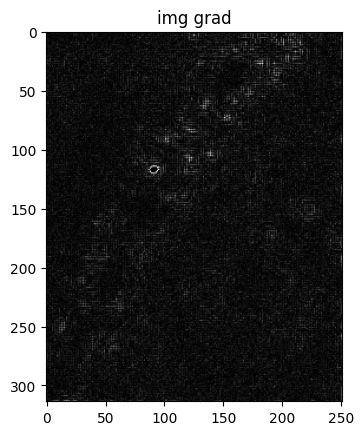

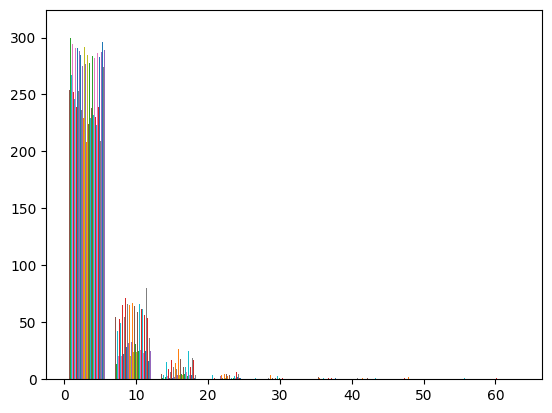

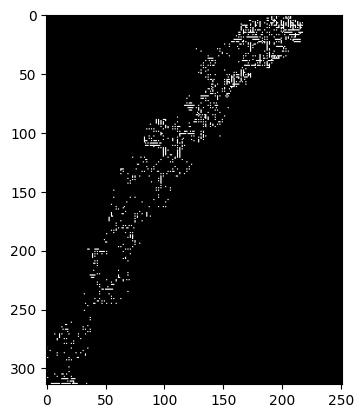

'\nblur_img_grad = cv2.medianBlur(img_grad, 7)\nblur_img_grad = cv2.bitwise_and(blur_img_grad,blur_img_grad,mask = object_mask)\nplt.imshow(blur_img_grad,cmap="gray")\nplt.show()\nmask = np.zeros_like(img)\n\nfor y,x in coords:\n    current_pixel_grad = blur_img_grad[y,x]\n    target_pixel_grad = img[y,x]\n    if  current_pixel_grad <= 50:\n        mask[y,x] = 255\n\nplt.imshow(mask,cmap="gray")\nplt.show()\n'

In [144]:
height,width = value_max_grad.shape
coords = []
for y in range(height):
    for x in range(width):
        if object_mask[y,x] == 255:
            coords.append((y,x))
def is_within_range(a, b):
    threshold = b * 0.05
    lower_bound = b - threshold
    upper_bound = b + threshold
    return lower_bound <= a <= upper_bound
    
idx = 17
img = X[idx]
label = Y[idx]

kernel_size = 1  
blur_size = 1          
img_grad = cv2.GaussianBlur(img, (blur_size,blur_size), 0)
img_grad = cv2.Laplacian(img_grad, cv2.CV_64F, ksize=kernel_size)
img_grad = np.absolute(img_grad)
img_grad = img_grad.astype(np.uint8)  # int_arr will be [1, 2, -4]
#img_grad = cv2.medianBlur(img_grad ,3)

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Training Image')
plt.subplot(1, 2, 2)
plt.imshow(label, cmap='gray')
plt.title('Training Label')
plt.tight_layout()
plt.show()

plt.imshow(img_grad, cmap='gray')
plt.title('img grad')
plt.show()

mask = np.zeros_like(img)

plt.hist(img_grad)
plt.show()
for y,x in coords:
    if  img_grad[y,x] > 8:
        mask[y,x] = 255
plt.imshow(mask,cmap='gray')
plt.show()

'''
mask_dif = np.zeros_like(mask)
height, width = mask.shape
for y in range(height):
    for x in range(width):
        if mask[y,x] == 255 :
           mask_dif[y,x] = 255
mask_dif = cv2.bitwise_and(mask_dif,mask_dif,mask = object_mask)
plt.imshow(mask_dif,cmap='gray')
plt.show()
'''


'''
blur_img_grad = cv2.medianBlur(img_grad, 7)
blur_img_grad = cv2.bitwise_and(blur_img_grad,blur_img_grad,mask = object_mask)
plt.imshow(blur_img_grad,cmap="gray")
plt.show()
mask = np.zeros_like(img)

for y,x in coords:
    current_pixel_grad = blur_img_grad[y,x]
    target_pixel_grad = img[y,x]
    if  current_pixel_grad <= 50:
        mask[y,x] = 255

plt.imshow(mask,cmap="gray")
plt.show()
'''



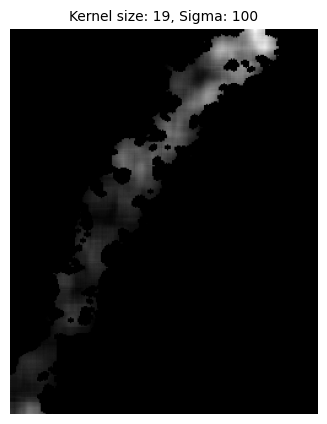

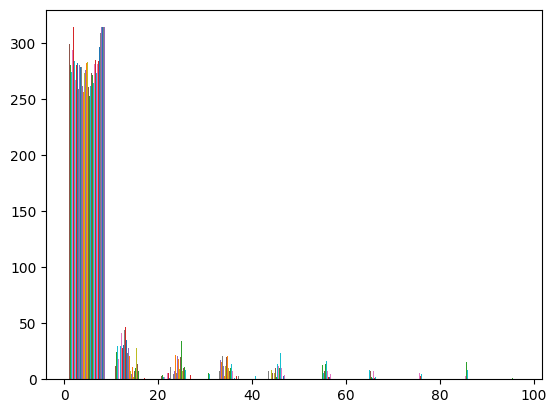

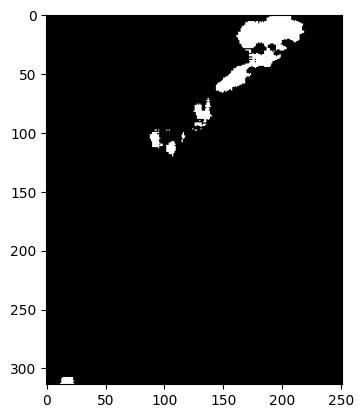

In [151]:
kernel_size = 19
sigma = 100
mask_blur = cv2.GaussianBlur(mask, (kernel_size, kernel_size), sigma)
mask_blur = cv2.bitwise_and(mask_blur,mask_blur,mask = object_mask)

plt.figure(figsize=(5, 5))  # Adjust figure size as needed
plt.imshow(mask_blur, cmap="gray")
plt.title(f"Kernel size: {kernel_size}, Sigma: {sigma}", fontsize=10)
plt.axis("off")  # Remove axes for cleaner visualization
plt.show()  # Display each plot separately
plt.hist(mask_blur)
plt.show()

_, mask_blur = cv2.threshold(mask_blur, 35, 255, cv2.THRESH_BINARY)

plt.imshow(mask_blur,cmap="gray")
plt.show()

In [9]:
from sklearn.metrics import f1_score, accuracy_score
predictions = []
X = x4
Y = y4

for idx, (img, label) in enumerate(zip(X, Y)):
    
    def lapla_blur(img):
        kernel_size = 1    
        blur_size = 1          
        img = cv2.GaussianBlur(img, (blur_size,blur_size), 0)
        img = cv2.Laplacian(img, cv2.CV_64F, ksize=kernel_size)
        img = np.absolute(img)
        return img
    x_grad = np.array([lapla_blur(x) for x in X])
    height, width = X[0].shape
    max_indices = np.zeros((height, width), dtype=np.uint8)
    max_grad = np.zeros((height, width), dtype=np.uint8)
    value_max_grad = np.zeros((height, width), dtype=np.uint8)
    for y in range(height):
        for x in range(width):
            # Extract pixel values for the current location from all images
            pixel_values = [image[y, x] for image in x_grad]
            # Find the index of the maximum value among all images
            max_index = np.argmax(pixel_values)
            max_grad[y,x] = np.max(pixel_values)
            max_indices[y, x] = max_index
            value_max_grad[y,x] = X[max_index][y][x]    
    blur_value_max_grad = cv2.medianBlur(value_max_grad,3)
    blur_max_grad = cv2.medianBlur(max_grad ,3)
    _, otsu_thresh_value = cv2.threshold(blur_value_max_grad, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, otsu_thresh_value_inv = cv2.threshold(blur_value_max_grad, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    _, otsu_thresh_grad= cv2.threshold(blur_max_grad, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    masked_image = cv2.bitwise_and(value_max_grad, otsu_thresh_value_inv)
    _, masked_image_threshold = cv2.threshold(masked_image, 40, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    highlighted_image = np.zeros_like(masked_image_threshold)
    for y in range(masked_image_threshold.shape[0]):
        for x in range(masked_image_threshold.shape[1]):
            if masked_image_threshold[y, x] != otsu_thresh_value_inv[y, x]:
                highlighted_image[y, x] = 255  # Set to white to highlight
    kernel_size = 41
    sigma = 150
    mask_blur = cv2.GaussianBlur(highlighted_image, (kernel_size, kernel_size), sigma)
    mask_blur = cv2.bitwise_and(mask_blur,mask_blur,mask = otsu_thresh_value_inv)
    _, object_mask = cv2.threshold(mask_blur, 10, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
    object_mask = cv2.morphologyEx(object_mask,cv2.MORPH_CLOSE,kernel,iterations=1)
   

    height,width = value_max_grad.shape
    coords = []
    for y in range(height):
        for x in range(width):
            if object_mask[y,x] == 255:
                coords.append((y,x))
    def is_within_range(a, b):
        threshold = b * 0.02
        lower_bound = b - threshold
        upper_bound = b + threshold
        return lower_bound <= a <= upper_bound
        

    kernel_size = 1  
    blur_size = 1          
    img_grad = cv2.GaussianBlur(img, (blur_size,blur_size), 0)
    img_grad = cv2.Laplacian(img_grad, cv2.CV_64F, ksize=kernel_size)
    img_grad = np.absolute(img_grad)
    img_grad = img_grad.astype(np.uint8)  # int_arr will be [1, 2, -4]
    mask = np.zeros_like(img)
    for y,x in coords:
        if  img_grad[y,x] >= 20:
            mask[y,x] = 255

    kernel_size = 19
    sigma = 15
    mask_blur = cv2.GaussianBlur(mask, (kernel_size, kernel_size), sigma)
    mask_blur = cv2.bitwise_and(mask_blur,mask_blur,mask = object_mask)
    _, mask_blur_thresh = cv2.threshold(mask_blur, 14, 255, cv2.THRESH_BINARY)
    predictions.append(mask_blur_thresh)
    '''
    
    plt.figure()
    plt.subplot(1, 4, 1)
    plt.imshow(mask, cmap='gray')
    plt.title('Predicted img')
    plt.subplot(1, 4, 2)
    plt.imshow(mask_blur, cmap='gray')
    plt.title('Gaussian img')
    plt.subplot(1, 4, 3)
    plt.imshow(mask_blur_thresh, cmap='gray')
    plt.title('threshold img')
    plt.subplot(1, 4, 4)
    plt.imshow(label, cmap='gray')
    plt.title('Ground Truth')
    plt.tight_layout()
    plt.show()
    '''
  
predictions_flat = np.array(predictions).flatten()/255
label_flat = Y.flatten()/255
print(predictions_flat.shape)
print(label_flat.shape)
print(predictions_flat)
print(label_flat)
print(np.unique(predictions_flat))
print(np.unique(label_flat))
f1 = f1_score(label_flat, predictions_flat)
accuracy = accuracy_score(label_flat, predictions_flat)
print("F1 Score:", f1, "Accuracy:", accuracy)


(1595800,)
(1595800,)
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]
[0. 1.]
[0. 1.]
F1 Score: 0.28373944006143964 Accuracy: 0.9807137485900489


In [81]:
def main(x1,y1):
    
    def lapla_blur(img):
        kernel_size = 1    
        blur_size = 1          
        img = cv2.GaussianBlur(img, (blur_size,blur_size), 0)
        img = cv2.Laplacian(img, cv2.CV_64F, ksize=kernel_size)
        img = np.absolute(img)
        return img

    x1_grad = np.array([lapla_blur(x) for x in x1])
    
    height, width = x1[0].shape
    
    max_indices = np.zeros((height, width), dtype=np.uint8)
    max_grad = np.zeros((height, width), dtype=np.uint8)
    value_max_grad = np.zeros((height, width), dtype=np.uint8)
    
    # Iterate over each pixel location
    for y in range(height):
        for x in range(width):
            # Extract pixel values for the current location from all images
            pixel_values = [image[y, x] for image in x1_grad]
            # Find the index of the maximum value among all images
            max_index = np.argmax(pixel_values)
            max_grad[y,x] = np.max(pixel_values)
            max_indices[y, x] = max_index
            value_max_grad[y,x] = x1[max_index][y][x]
    plt.imshow(value_max_grad, cmap='gray')
    plt.show()
    blur_max_grad = cv2.medianBlur(value_max_grad,5)
    
    _, otsu_thresh_inv = cv2.threshold(blur_max_grad, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, otsu_thresh= cv2.threshold(blur_max_grad, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    coords = []
    for y in range(height):
        for x in range(width):
            if otsu_thresh_inv[y,x] == 0:
                coords.append((y,x))
    def is_within_range(a, b):
        threshold = b * 0.0  # 20% of B
        lower_bound = b - threshold
        upper_bound = b + threshold
        return lower_bound <= a <= upper_bound
    img = x1[0]
    kernel_size = 1    
    blur_size = 1          
    img = cv2.GaussianBlur(img, (blur_size,blur_size), 0)
    img_grad = cv2.Laplacian(img, cv2.CV_64F, ksize=kernel_size)
    img_grad = np.absolute(img_grad)
    height, width = img.shape
    mask = np.zeros_like(img)
    for y,x in coords:
        current_pixel = img_grad[y,x]
        target_pixel = max_grad[y,x]
        if is_within_range(current_pixel,target_pixel):
            mask[y,x] = 255


    predictions = []
    for img,label in zip(x1,y1):        
        kernel_size = 1    
        blur_size = 1          
        img = cv2.GaussianBlur(img, (blur_size,blur_size), 0)
        img_grad = cv2.Laplacian(img, cv2.CV_64F, ksize=kernel_size)
        img_grad = np.absolute(img_grad)
        
        height, width = img.shape
        
        mask = np.zeros_like(img)
        
        for y,x in coords:
            current_pixel = img_grad[y,x]
            target_pixel = max_grad[y,x]
            if is_within_range(current_pixel,target_pixel):
                mask[y,x] = 255
        kernel_size = 27
        sigma = 50
        mask_blur = cv2.GaussianBlur(mask, (kernel_size, kernel_size), sigma)
       
        mask_blur = cv2.bitwise_and(mask_blur,mask_blur,mask = otsu_thresh)
        _, mask_blur = cv2.threshold(mask_blur, 16, 255, cv2.THRESH_BINARY)
        predictions.append(mask_blur)
        
        plt.figure()
        plt.subplot(1, 3, 1)
        plt.imshow(mask, cmap='gray')
        plt.title('Predicted Image')

        # Plot the corresponding label
        plt.subplot(1, 3, 2)
        plt.imshow(mask_blur, cmap='gray')
        plt.title('Gaussian Image')
        
        # Plot the corresponding label
        plt.subplot(1, 3, 3)
        plt.imshow(label, cmap='gray')
        plt.title('Ground Truth')

        
        
        plt.tight_layout()
        plt.show()
        
    predictions_flat = np.array(predictions).flatten()/255
    label_flat = y1.flatten()/255
    print(predictions_flat.shape)
    print(label_flat.shape)
    print(predictions_flat)
    print(label_flat)
    print(np.unique(predictions_flat))
    print(np.unique(label_flat))
    f1 = f1_score(label_flat, predictions_flat)
    accuracy = accuracy_score(label_flat, predictions_flat)
    print("F1 Score:", f1, "Accuracy:", accuracy)

#main(x3,y3)
    

In [12]:
# 50-50-40-30
from sklearn.metrics import f1_score, accuracy_score
predictions = []
X = x2
Y = y2
for img,label in zip(X,Y):
    
    def lapla_blur(img):
        kernel_size = 1    
        blur_size = 1          
        img = cv2.GaussianBlur(img, (blur_size,blur_size), 0)
        img = cv2.Laplacian(img, cv2.CV_64F, ksize=kernel_size)
        img = np.absolute(img)
        return img
    x_grad = np.array([lapla_blur(x) for x in X])
    height, width = X[0].shape
    max_indices = np.zeros((height, width), dtype=np.uint8)
    max_grad = np.zeros((height, width), dtype=np.uint8)
    value_max_grad = np.zeros((height, width), dtype=np.uint8)
    for y in range(height):
        for x in range(width):
            # Extract pixel values for the current location from all images
            pixel_values = [image[y, x] for image in x_grad]
            # Find the index of the maximum value among all images
            max_index = np.argmax(pixel_values)
            max_grad[y,x] = np.max(pixel_values)
            max_indices[y, x] = max_index
            value_max_grad[y,x] = X[max_index][y][x]    
    blur_value_max_grad = cv2.medianBlur(value_max_grad,3)
    blur_max_grad = cv2.medianBlur(max_grad ,3)
    _, otsu_thresh_value = cv2.threshold(blur_value_max_grad, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, otsu_thresh_value_inv = cv2.threshold(blur_value_max_grad, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    _, otsu_thresh_grad= cv2.threshold(blur_max_grad, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    masked_image = cv2.bitwise_and(value_max_grad, otsu_thresh_value_inv)
    _, masked_image_threshold = cv2.threshold(masked_image, 40, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    highlighted_image = np.zeros_like(masked_image_threshold)
    for y in range(masked_image_threshold.shape[0]):
        for x in range(masked_image_threshold.shape[1]):
            if masked_image_threshold[y, x] != otsu_thresh_value_inv[y, x]:
                highlighted_image[y, x] = 255  # Set to white to highlight
    kernel_size = 41
    sigma = 150
    mask_blur = cv2.GaussianBlur(highlighted_image, (kernel_size, kernel_size), sigma)
    mask_blur = cv2.bitwise_and(mask_blur,mask_blur,mask = otsu_thresh_value_inv)
    _, object_mask = cv2.threshold(mask_blur, 10, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
    object_mask = cv2.morphologyEx(object_mask,cv2.MORPH_CLOSE,kernel,iterations=1)
   

    height,width = value_max_grad.shape
    coords = []
    for y in range(height):
        for x in range(width):
            if object_mask[y,x] == 255:
                coords.append((y,x))
    def is_within_range(a, b):
        threshold = b * 0.02
        lower_bound = b - threshold
        upper_bound = b + threshold
        return lower_bound <= a <= upper_bound
        

    kernel_size = 1  
    blur_size = 1          
    img_grad = cv2.GaussianBlur(img, (blur_size,blur_size), 0)
    img_grad = cv2.Laplacian(img_grad, cv2.CV_64F, ksize=kernel_size)
    img_grad = np.absolute(img_grad)
    img_grad = img_grad.astype(np.uint8)  # int_arr will be [1, 2, -4]
    mask = np.zeros_like(img)
    for y,x in coords:
        if  img_grad[y,x] >= 20:
            mask[y,x] = 255

    kernel_size = 19
    sigma = 15
    mask_blur = cv2.GaussianBlur(mask, (kernel_size, kernel_size), sigma)
    mask_blur = cv2.bitwise_and(mask_blur,mask_blur,mask = object_mask)
    _, mask_blur_thresh = cv2.threshold(mask_blur, 10, 255, cv2.THRESH_BINARY)
    '''
    plt.figure()
    plt.subplot(1, 4, 1)
    plt.imshow(mask, cmap='gray')
    plt.title('Predicted img')
    plt.subplot(1, 4, 2)
    plt.imshow(mask_blur, cmap='gray')
    plt.title('Gaussian img')
    plt.subplot(1, 4, 3)
    plt.imshow(mask_blur_thresh, cmap='gray')
    plt.title('threshold img')
    plt.subplot(1, 4, 4)
    plt.imshow(label, cmap='gray')
    plt.title('Ground Truth')
    plt.tight_layout()
    plt.show()
    '''
    predictions.append(mask_blur_thresh)
predictions_flat = np.array(predictions).flatten()/255
label_flat = Y.flatten()/255
print(predictions_flat.shape)
print(label_flat.shape)
print(predictions_flat)
print(label_flat)
print(np.unique(predictions_flat))
print(np.unique(label_flat))
f1 = f1_score(label_flat, predictions_flat)
accuracy = accuracy_score(label_flat, predictions_flat)
print("F1 Score:", f1, "Accuracy:", accuracy)

(2647260,)
(2647260,)
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]
[0. 1.]
[0. 1.]
F1 Score: 0.49334538802800615 Accuracy: 0.9817947613759133


In [6]:
def generate_segmentation_map(X):
    predictions = []
    for img in X:
        
        def lapla_blur(img):
            kernel_size = 1    
            blur_size = 1          
            img = cv2.GaussianBlur(img, (blur_size,blur_size), 0)
            img = cv2.Laplacian(img, cv2.CV_64F, ksize=kernel_size)
            img = np.absolute(img)
            return img
        x_grad = np.array([lapla_blur(x) for x in X])
        height, width = X[0].shape
        max_indices = np.zeros((height, width), dtype=np.uint8)
        max_grad = np.zeros((height, width), dtype=np.uint8)
        value_max_grad = np.zeros((height, width), dtype=np.uint8)
        for y in range(height):
            for x in range(width):
                # Extract pixel values for the current location from all images
                pixel_values = [image[y, x] for image in x_grad]
                # Find the index of the maximum value among all images
                max_index = np.argmax(pixel_values)
                max_grad[y,x] = np.max(pixel_values)
                max_indices[y, x] = max_index
                value_max_grad[y,x] = X[max_index][y][x]    
        blur_value_max_grad = cv2.medianBlur(value_max_grad,3)
        blur_max_grad = cv2.medianBlur(max_grad ,3)
        #_, otsu_thresh_value = cv2.threshold(blur_value_max_grad, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        _, otsu_thresh_value_inv = cv2.threshold(blur_value_max_grad, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        #_, otsu_thresh_grad= cv2.threshold(blur_max_grad, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        masked_image = cv2.bitwise_and(value_max_grad, otsu_thresh_value_inv)
        _, masked_image_threshold = cv2.threshold(masked_image, 40, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        highlighted_image = np.zeros_like(masked_image_threshold)
        for y in range(masked_image_threshold.shape[0]):
            for x in range(masked_image_threshold.shape[1]):
                if masked_image_threshold[y, x] != otsu_thresh_value_inv[y, x]:
                    highlighted_image[y, x] = 255  # Set to white to highlight
        kernel_size = 41
        sigma = 150
        mask_blur = cv2.GaussianBlur(highlighted_image, (kernel_size, kernel_size), sigma)
        mask_blur = cv2.bitwise_and(mask_blur,mask_blur,mask = otsu_thresh_value_inv)
        _, object_mask = cv2.threshold(mask_blur, 10, 255, cv2.THRESH_BINARY)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
        object_mask = cv2.morphologyEx(object_mask,cv2.MORPH_CLOSE,kernel,iterations=1)
       
    
        height,width = value_max_grad.shape
        coords = []
        for y in range(height):
            for x in range(width):
                if object_mask[y,x] == 255:
                    coords.append((y,x))
        def is_within_range(a, b):
            threshold = b * 0.02
            lower_bound = b - threshold
            upper_bound = b + threshold
            return lower_bound <= a <= upper_bound
            
    
        kernel_size = 1  
        blur_size = 1          
        img_grad = cv2.GaussianBlur(img, (blur_size,blur_size), 0)
        img_grad = cv2.Laplacian(img_grad, cv2.CV_64F, ksize=kernel_size)
        img_grad = np.absolute(img_grad)
        img_grad = img_grad.astype(np.uint8)  # int_arr will be [1, 2, -4]
        mask = np.zeros_like(img)
        for y,x in coords:
            if  img_grad[y,x] >= 20:
                mask[y,x] = 255
    
        kernel_size = 19
        sigma = 15
        mask_blur = cv2.GaussianBlur(mask, (kernel_size, kernel_size), sigma)
        mask_blur = cv2.bitwise_and(mask_blur,mask_blur,mask = object_mask)
        _, mask_blur_thresh = cv2.threshold(mask_blur, 10, 255, cv2.THRESH_BINARY)
        predictions.append(mask_blur_thresh)
        
    return predictions

In [10]:
X,Y = x2,y2
predictions = generate_segmentation_map(X)
predictions_flat = np.array(predictions).flatten()/255
label_flat = Y.flatten()/255
print(predictions_flat.shape)
print(label_flat.shape)
print(predictions_flat)
print(label_flat)
print(np.unique(predictions_flat))
print(np.unique(label_flat))
f1 = f1_score(label_flat, predictions_flat)
accuracy = accuracy_score(label_flat, predictions_flat)
print("F1 Score:", f1, "Accuracy:", accuracy)

(1595800,)
(1595800,)
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]
[0. 1.]
[0. 1.]
F1 Score: 0.30797374773687386 Accuracy: 0.977005890462464


/var/folders/9c/4nfptrpn4xn90xdbpp0vkpz00000gn/T/ipykernel_10867/1594867816.py:30: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


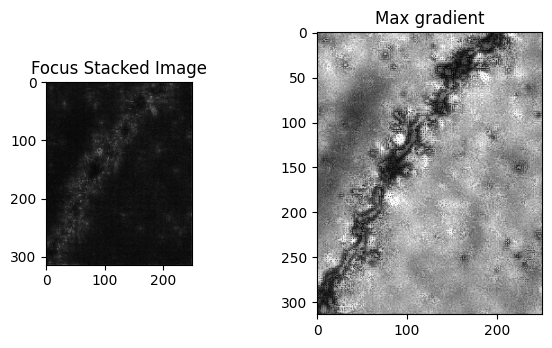

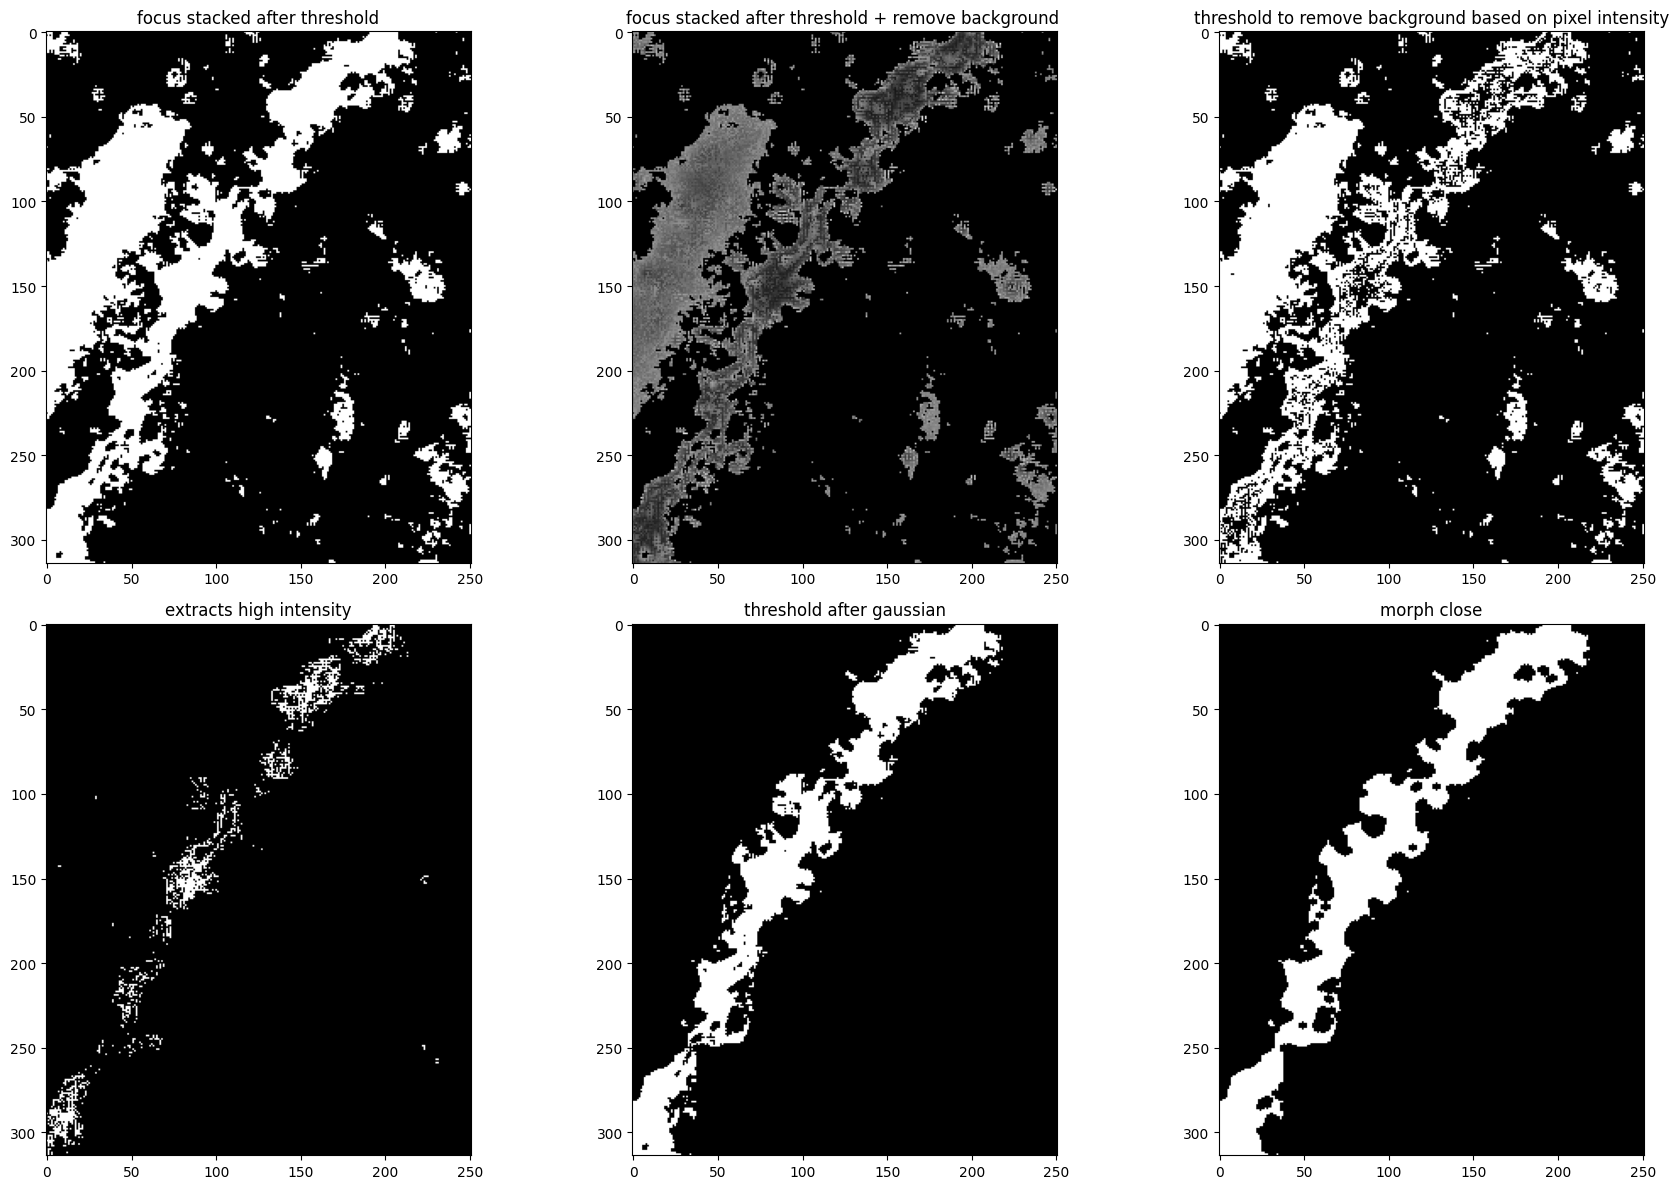

Processing:   0%|                                        | 0/23 [00:00<?, ?it/s]

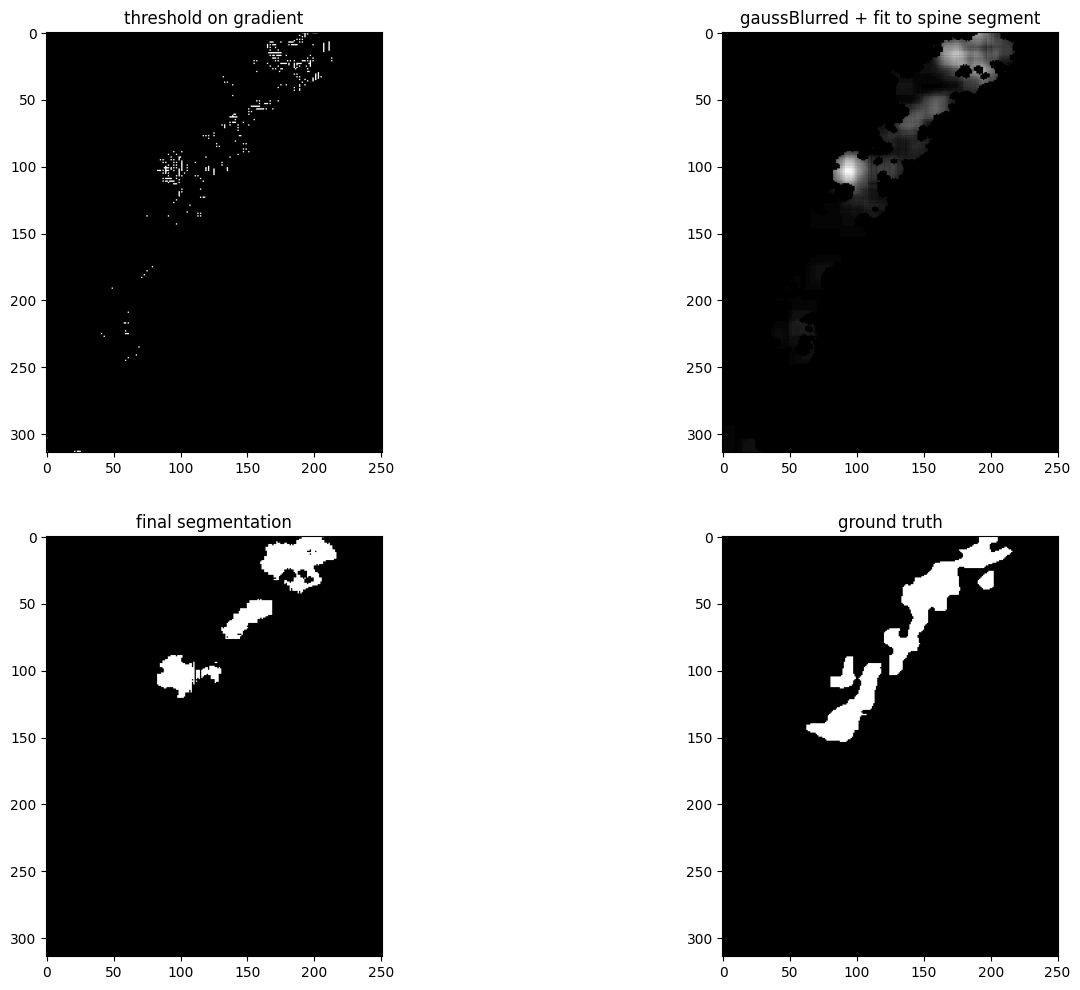

Processing: 100%|███████████████████████████████| 23/23 [00:00<00:00, 70.61it/s]

(1, 314, 251)


In [75]:
from tqdm import tqdm

def generate_segmentation_map(X):

    def lapla_blur(img):
            kernel_size = 1    
            img = cv2.Laplacian(img, cv2.CV_64F, ksize=kernel_size)
            return np.absolute(img)
    x_grad = np.array([lapla_blur(x) for x in X])
    height, width = X[0].shape
    max_index = np.zeros((height, width), dtype=np.uint8)
    max_grad = np.zeros((height, width), dtype=np.uint8)
    value_max_grad = np.zeros((height, width), dtype=np.uint8)

    # generate the in-focused map
    for y in range(height):
        for x in range(width):
            pixel_values = [image[y, x] for image in x_grad]
            max_index = np.argmax(pixel_values)
            max_grad[y,x] = np.max(pixel_values)
            value_max_grad[y,x] = X[max_index][y][x]

    plt.figure()
    plt.subplot(1, 3, 1)
    plt.imshow(max_grad, cmap='gray')
    plt.title('Focus Stacked Image')
    plt.subplot(1, 2, 2)
    plt.imshow(value_max_grad, cmap='gray')
    plt.title('Max gradient')
    plt.tight_layout()
    plt.show()



    fig, axs = plt.subplots(2, 3, figsize=(18, 12))





    
    blur_value_max_grad = cv2.medianBlur(value_max_grad,3)
    _, otsu_thresh_value_inv = cv2.threshold(blur_value_max_grad, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    #plt.subplot(1, 3, 1)
    #plt.imshow(otsu_thresh_value_inv,cmap='gray')
    #plt.title("focus stacked after threshold")
    axs[0, 0].imshow(otsu_thresh_value_inv,cmap='gray')
    axs[0, 0].set_title("focus stacked after threshold")
    #plt.show()


    
    masked_image = cv2.bitwise_and(value_max_grad, otsu_thresh_value_inv)
    #plt.subplot(1, 3, 2)
    #plt.imshow(masked_image,cmap='gray')
    #plt.title('focus stacked after threshold + remove background ')
    axs[0, 1].imshow(masked_image,cmap='gray')
    axs[0, 1].set_title('focus stacked after threshold + remove background ')
    #plt.show()


    _, masked_image_threshold = cv2.threshold(masked_image, 40, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    #plt.subplot(1, 3, 3)
    #plt.imshow(masked_image_threshold,cmap='gray')
    #plt.title("threshold to remove background based on pixel intensity")
    #plt.show()
    axs[0, 2].imshow(masked_image_threshold,cmap='gray')
    axs[0, 2].set_title("threshold to remove background based on pixel intensity")
    
    highlighted_image = np.zeros_like(masked_image_threshold)
    for y in range(masked_image_threshold.shape[0]):
        for x in range(masked_image_threshold.shape[1]):
            if masked_image_threshold[y, x] != otsu_thresh_value_inv[y, x]:
                highlighted_image[y, x] = 255     
    #plt.subplot(2, 3, 1)
    #plt.imshow(highlighted_image,cmap='gray')
    #plt.title("extracts the pixels within the segmentation that have high intensity")
    axs[1, 0].imshow(highlighted_image,cmap='gray')
    axs[1, 0].set_title("extracts high intensity")
    #plt.show()



    
    kernel_size = 41
    sigma = 150
    mask_blur = cv2.GaussianBlur(highlighted_image, (kernel_size, kernel_size), sigma)
    mask_blur = cv2.bitwise_and(mask_blur,mask_blur,mask = otsu_thresh_value_inv)
    _, object_mask = cv2.threshold(mask_blur, 10, 255, cv2.THRESH_BINARY)
    #plt.subplot(2, 3, 2)
    #plt.imshow(object_mask,cmap='gray')
    #plt.title("threshold after gaussian")
    axs[1, 1].imshow(object_mask,cmap='gray')
    axs[1, 1].set_title("threshold after gaussian")
    #plt.show()
    

    
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
    object_mask = cv2.morphologyEx(object_mask,cv2.MORPH_CLOSE,kernel,iterations=1)
    #plt.subplot(2, 3, 3)
    #plt.imshow(object_mask,cmap='gray')
    #plt.title("morph close")
    axs[1, 2].imshow(object_mask,cmap='gray')
    axs[1, 2].set_title("morph close")
    # Adjust layout to prevent overlap
    plt.tight_layout()
    
    # Save the plot
    plt.savefig('subplot_figure.png')
    plt.show()


    predictions = []
    count = 0
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    for img in tqdm(X, desc="Processing", total=len(X)):
        count += 1
        if count != 16:
            continue
        coords = np.argwhere(object_mask == 255)
        kernel_size = 1  
        img_grad = cv2.Laplacian(img, cv2.CV_64F, ksize=kernel_size)
        img_grad = np.absolute(img_grad)
        img_grad = img_grad.astype(np.uint8)
        

        
        mask = np.zeros_like(img_grad)
        coords_array = np.array(coords)
        indices = np.where(img_grad[coords_array[:, 0], coords_array[:, 1]] >= 20)
        mask[coords_array[indices][:, 0], coords_array[indices][:, 1]] = 255
        axs[0, 0].imshow(mask,cmap='gray')
        axs[0, 0].set_title("threshold on gradient")
        
        #plt.imshow(mask,cmap="gray")
        #plt.title("thresholded gradient")
        #plt.show()

        kernel_size = 19
        sigma = 15
        mask_blur = cv2.GaussianBlur(mask, (kernel_size, kernel_size), sigma)
        mask_blur = cv2.bitwise_and(mask_blur,mask_blur,mask = object_mask)
        axs[0, 1].imshow(mask_blur,cmap='gray')
        axs[0, 1].set_title("gaussBlurred + fit to spine segment")
        #plt.imshow(mask_blur,cmap="gray")
        #plt.title("GaussianBlurred")
        #plt.show()


        
        _, mask_blur_thresh = cv2.threshold(mask_blur, 10, 255, cv2.THRESH_BINARY)
        axs[1, 0].imshow(mask_blur_thresh,cmap='gray')
        axs[1, 0].set_title("final segmentation")

        axs[1, 1].imshow(y3[count],cmap='gray')
        axs[1, 1].set_title("ground truth")
        plt.savefig("p.jpg")
        plt.show()
        #plt.imshow(mask_blur_thresh,cmap='gray')
        #plt.show()
        predictions.append(mask_blur_thresh)
        
    return np.array(predictions, dtype = np.uint8)

predictions = generate_segmentation_map(X)
print(predictions.shape)
